# Complete Guide to Geospatial Analysis

### What is Geospatial Analysis?
**Geospatial analysis** is the science of analyzing data that has a geographic or location component. It helps us answer questions like:
- **Where** are events happening?
- **Why** do they occur in specific locations?
- **What patterns** exist across different regions?

### Real-World Applications
| Domain | Application Example |
|--------|---------------------|
| Urban Planning | Deciding optimal locations for schools, hospitals |
| Environment | Monitoring deforestation, pollution tracking |
| Disaster Management | Mapping flood zones, earthquake impact areas |
| Business | Store location analysis, delivery route optimization |
| Healthcare | Disease outbreak mapping, hospital accessibility |

## Part 1: Setup and Understanding Geographic Data

### What makes data "geographic"?
Regular data becomes **geographic data** when it includes location information (coordinates).

| Regular Data | Geographic Data |
|--------------|-----------------|
| City: Mumbai | City: Mumbai, Lat: 19.08°N, Lon: 72.88°E |
| Temperature: 35°C | Temperature: 35°C at location (19.08, 72.88) |

### Key Geographic Terms
| Term | Definition | Example |
|------|------------|---------|
| **Latitude** | North-South position (0° at equator) | 28.61°N for Delhi |
| **Longitude** | East-West position (0° at Prime Meridian) | 77.21°E for Delhi |
| **Point** | A single location (0D) | City center |
| **Line** | Connected points (1D) | Road, river |
| **Polygon** | Enclosed area (2D) | Country boundary, lake |

### Python Libraries for Geospatial Analysis
| Library | Purpose |
|---------|---------|
| **GeoPandas** | Extends pandas for spatial data operations |
| **Shapely** | Create and manipulate geometric shapes |
| **Folium** | Create interactive web maps |
| **Matplotlib** | Static map visualizations |

In [ ]:
# %pip install geopandas shapely folium matplotlib geopy rasterio

In [23]:
# Import Required Libraries
import pandas as pd                          # Data manipulation
import numpy as np                           # Numerical operations
import geopandas as gpd                      # Geospatial data handling (extends pandas)
from shapely.geometry import Point, Polygon, LineString  # Creating geometric shapes
import matplotlib.pyplot as plt              # Static visualizations
import folium                                # Interactive web maps

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")
print("\nLibrary versions:")
print(f"  GeoPandas: {gpd.__version__}")
print(f"  Folium: {folium.__version__}")

All libraries imported successfully!

Library versions:
  GeoPandas: 1.0.1
  Folium: 0.14.0


In [24]:
# Load the Landslide Dataset
df = pd.read_csv('TASK.csv')

# Quick overview
print(f"Dataset: {df.shape[0]} landslide events with {df.shape[1]} attributes")
print(f"\nGeographic extent:")
print(f"  Latitude:  {df['latitude'].min():.2f}° to {df['latitude'].max():.2f}°")
print(f"  Longitude: {df['longitude'].min():.2f}° to {df['longitude'].max():.2f}°")

# Preview the data
df[['date', 'countryname', 'latitude', 'longitude', 'hazard_type', 'fatalities']].head()

Dataset: 9564 landslide events with 34 attributes

Geographic extent:
  Latitude:  -46.77° to 72.63°
  Longitude: -170.80° to 179.42°


,date,countryname,latitude,longitude,hazard_type,fatalities
0,01/02/2007,United Kingdom,54.549400,-3.587500,landslide,1.0
1,01/03/2007,Peru,-10.383800,-75.426700,landslide,NaN
2,01/05/2007,Brazil,-22.282346,-42.536362,landslide,7.0
3,01/05/2007,Brazil,-22.045200,-42.673400,landslide,2.0
4,01/05/2007,Brazil,-23.231100,-46.613600,landslide,1.0


## Part 2: Coordinate Reference Systems (CRS)

### The Fundamental Problem
Earth is a **3D sphere** (technically an oblate spheroid), but maps are **2D flat surfaces**. 
How do we accurately represent locations on a flat surface?

### What is a CRS?
A **Coordinate Reference System** defines how coordinates (numbers) correspond to actual locations on Earth.
Think of it as a standardized "address system" for the entire planet.

### Two Types of CRS

| Type | Units | Description | Example |
|------|-------|-------------|---------|
| **Geographic CRS** | Degrees | Uses latitude/longitude on curved Earth | WGS84 (EPSG:4326) |
| **Projected CRS** | Meters/Feet | Flattened onto a plane | UTM, Web Mercator |

### Common EPSG Codes (Memorize These!)
| EPSG Code | Name | Use Case |
|-----------|------|----------|
| **4326** | WGS84 | GPS coordinates, storing global data |
| **3857** | Web Mercator | Google Maps, web mapping |
| **32643** | UTM Zone 43N | Accurate measurements in India |

### Why CRS Matters
**Wrong CRS = Wrong Location!**
- If you mix CRS without converting, points appear in wrong places
- Distance and area calculations will be incorrect
- Spatial operations (joins, buffers) will fail

In [25]:
# Converting DataFrame to GeoDataFrame
# The key difference: GeoDataFrame has a 'geometry' column for spatial operations

# Step 1: Create Point objects from coordinates
# IMPORTANT: Point takes (longitude, latitude) - X before Y!
geometry = [Point(lon, lat) for lon, lat in zip(df['longitude'], df['latitude'])]

# Step 2: Create GeoDataFrame with CRS
# We use EPSG:4326 (WGS84) because our data is in lat/lon degrees
gdf = gpd.GeoDataFrame(df, geometry=geometry, crs='EPSG:4326')

print("GeoDataFrame created!")
print(f"  Number of features: {len(gdf)}")
print(f"  CRS: {gdf.crs} ({gdf.crs.name})")
print(f"\nExample geometry:")
print(f"  Point: {gdf.iloc[0].geometry}")
print(f"  X (Longitude): {gdf.iloc[0].geometry.x:.4f}")
print(f"  Y (Latitude): {gdf.iloc[0].geometry.y:.4f}")

GeoDataFrame created!
  Number of features: 9564
  CRS: EPSG:4326 (WGS 84)

Example geometry:
  Point: POINT (-3.5875 54.5494)
  X (Longitude): -3.5875
  Y (Latitude): 54.5494


In [26]:
# CRS Transformation (Reprojection)
# Converting from one coordinate system to another

# Original: WGS84 (Geographic CRS - degrees)
print("BEFORE: WGS84 (EPSG:4326) - Geographic CRS")
print(f"  Units: Degrees")
print(f"  Sample: ({gdf.iloc[0].geometry.x:.4f}°, {gdf.iloc[0].geometry.y:.4f}°)")

# Transform to Web Mercator (Projected CRS - meters)
gdf_mercator = gdf.to_crs('EPSG:3857')

print("\nAFTER: Web Mercator (EPSG:3857) - Projected CRS")
print(f"  Units: Meters")
print(f"  Sample: ({gdf_mercator.iloc[0].geometry.x:,.0f}m, {gdf_mercator.iloc[0].geometry.y:,.0f}m)")

# When to use which?
print("\n--- CRS Selection Guide ---")
print("EPSG:4326 (WGS84):     Store data, GPS, global datasets")
print("EPSG:3857 (Mercator):  Web maps, visualization")
print("UTM zones:             Accurate distance/area calculations")

BEFORE: WGS84 (EPSG:4326) - Geographic CRS
  Units: Degrees
  Sample: (-3.5875°, 54.5494°)

AFTER: Web Mercator (EPSG:3857) - Projected CRS
  Units: Meters
  Sample: (-399,359m, 7,274,900m)

--- CRS Selection Guide ---
EPSG:4326 (WGS84):     Store data, GPS, global datasets
EPSG:3857 (Mercator):  Web maps, visualization
UTM zones:             Accurate distance/area calculations


## Part 3: Map Projections

### The Orange Peel Problem
Imagine peeling an orange and flattening the peel on a table - it tears and stretches!
This is exactly the challenge with map projections.

### What is a Map Projection?
A **mathematical transformation** that converts the curved 3D Earth surface onto a flat 2D map.

### The Unavoidable Trade-Off
**No projection is perfect!** Every projection distorts at least one of:

| Property | What it means | Projection that preserves it |
|----------|---------------|------------------------------|
| **Shape** | Local angles and shapes | Mercator (Conformal) |
| **Area** | Relative sizes | Equal-Area (Albers, Mollweide) |
| **Distance** | Distances from a point | Equidistant |
| **Direction** | Compass bearings | Azimuthal |

### Famous Projection Distortions
- **Mercator**: Greenland appears as large as Africa (actually 14x smaller!)
- **Equal-Area**: Shapes look "squished" but sizes are accurate
- **Robinson**: Compromise - nothing is perfect, but nothing is too bad

### Choosing the Right Projection
| Task | Best Projection |
|------|-----------------|
| Navigation | Mercator |
| Statistical maps (comparing countries) | Equal-Area |
| World atlases | Robinson (compromise) |
| Local area analysis | UTM (for your region) |

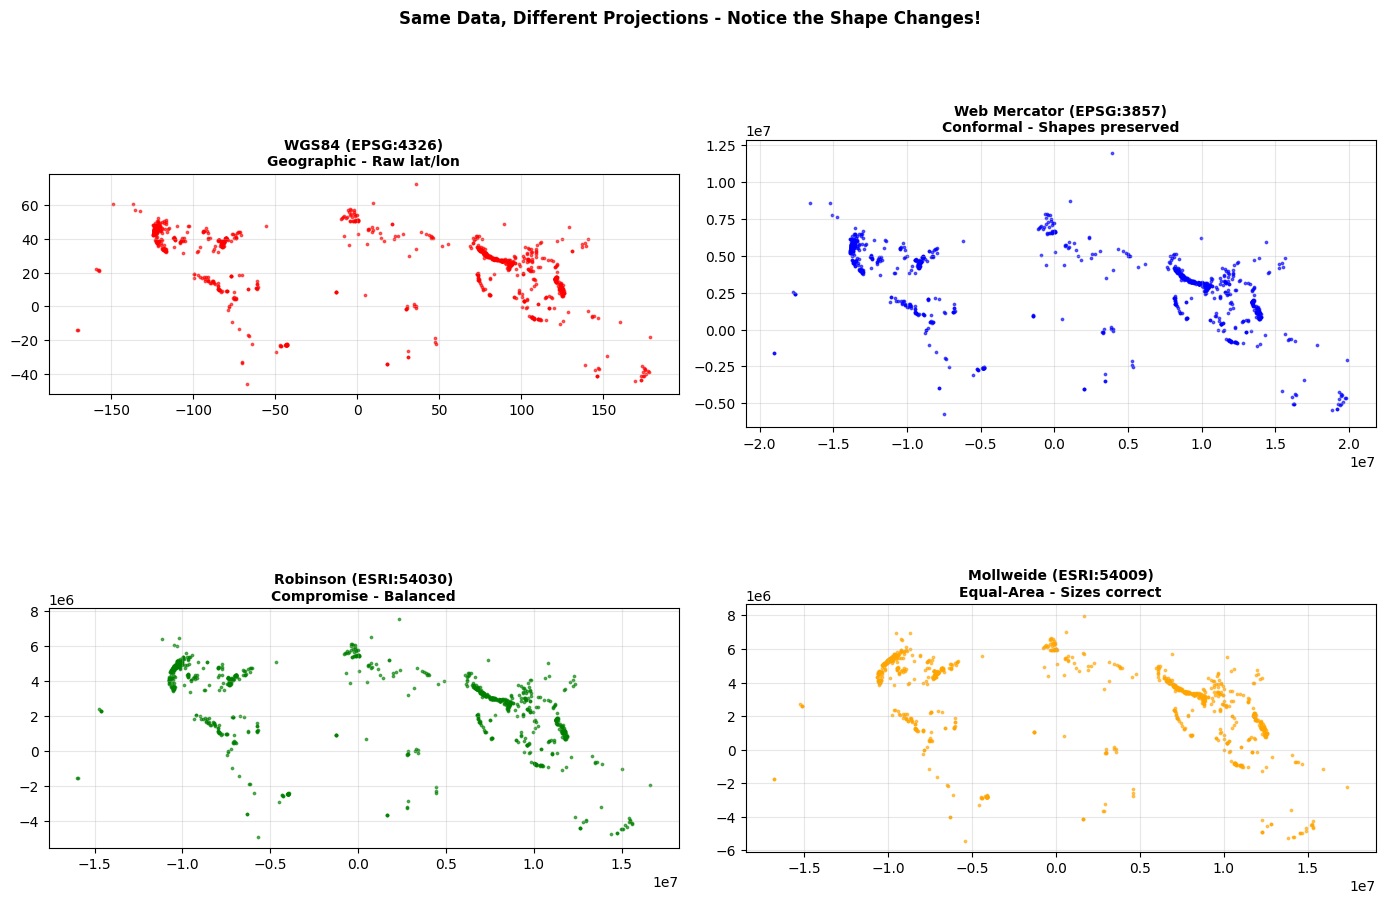

In [27]:
# Visualizing Different Map Projections
# Same data looks different in each projection!

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
sample = gdf.sample(min(1000, len(gdf)), random_state=42)

projections = {
    'WGS84 (EPSG:4326)\nGeographic - Raw lat/lon': 'EPSG:4326',
    'Web Mercator (EPSG:3857)\nConformal - Shapes preserved': 'EPSG:3857',
    'Robinson (ESRI:54030)\nCompromise - Balanced': 'ESRI:54030',
    'Mollweide (ESRI:54009)\nEqual-Area - Sizes correct': 'ESRI:54009'
}

for idx, (title, epsg) in enumerate(projections.items()):
    ax = axes[idx // 2, idx % 2]
    try:
        sample.to_crs(epsg).plot(ax=ax, markersize=3, color=['red', 'blue', 'green', 'orange'][idx], alpha=0.6)
        ax.set_title(title, fontsize=10, fontweight='bold')
        ax.grid(True, alpha=0.3)
    except Exception as e:
        ax.text(0.5, 0.5, f'Error: {str(e)[:30]}', ha='center', transform=ax.transAxes)

plt.suptitle('Same Data, Different Projections - Notice the Shape Changes!', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## Part 4: Geospatial Data Formats

### Two Fundamental Types: Vector vs Raster

| Aspect | Vector Data | Raster Data |
|--------|-------------|-------------|
| **Representation** | Points, Lines, Polygons | Grid of cells (pixels) |
| **Best for** | Discrete features | Continuous phenomena |
| **Examples** | Cities, roads, boundaries | Satellite images, elevation, temperature |
| **File size** | Generally smaller | Can be very large |
| **Precision** | Exact coordinates | Limited by cell size (resolution) |

### Vector Data Formats
| Format | Extension | Pros | Cons |
|--------|-----------|------|------|
| **Shapefile** | .shp (+.dbf, .shx) | Industry standard | Multiple files required |
| **GeoJSON** | .geojson | Human-readable, web-friendly | Large file size for complex data |
| **GeoPackage** | .gpkg | Single file, modern, SQLite-based | Less widely supported |
| **KML** | .kml | Google Earth compatible | Limited attributes |

### Raster Data Formats
| Format | Extension | Use Case |
|--------|-----------|----------|
| **GeoTIFF** | .tif | Satellite imagery, elevation models |
| **NetCDF** | .nc | Climate and ocean data |
| **JPEG2000** | .jp2 | Compressed satellite imagery |

### When to Use Which?
- **Vector**: When you need exact boundaries (countries, roads, buildings)
- **Raster**: When data varies continuously (temperature, elevation, satellite photos)

In [28]:
# Understanding Geospatial Data Formats (Demonstration without creating files)

# Example: GeoJSON structure (what it looks like internally)
sample_geojson = {
    "type": "FeatureCollection",
    "features": [
        {
            "type": "Feature",
            "geometry": {
                "type": "Point",
                "coordinates": [77.21, 28.61]  # [longitude, latitude]
            },
            "properties": {
                "name": "Delhi",
                "country": "India",
                "population": 30000000
            }
        }
    ]
}

print("GeoJSON Structure Example:")
print("-" * 40)
import json
print(json.dumps(sample_geojson, indent=2))

print("\n" + "-" * 40)
print("Reading geospatial files with GeoPandas:")
print("-" * 40)
print("""
# Reading different formats (all use the same function!)
gdf = gpd.read_file('data.shp')       # Shapefile
gdf = gpd.read_file('data.geojson')   # GeoJSON
gdf = gpd.read_file('data.gpkg')      # GeoPackage

# Writing to different formats
gdf.to_file('output.shp')                              # Shapefile
gdf.to_file('output.geojson', driver='GeoJSON')        # GeoJSON
gdf.to_file('output.gpkg', driver='GPKG')              # GeoPackage
""")

GeoJSON Structure Example:
----------------------------------------
{
  "type": "FeatureCollection",
  "features": [
    {
      "type": "Feature",
      "geometry": {
        "type": "Point",
        "coordinates": [
          77.21,
          28.61
        ]
      },
      "properties": {
        "name": "Delhi",
        "country": "India",
        "population": 30000000
      }
    }
  ]
}

----------------------------------------
Reading geospatial files with GeoPandas:
----------------------------------------

# Reading different formats (all use the same function!)
gdf = gpd.read_file('data.shp')       # Shapefile
gdf = gpd.read_file('data.geojson')   # GeoJSON
gdf = gpd.read_file('data.gpkg')      # GeoPackage

# Writing to different formats
gdf.to_file('output.shp')                              # Shapefile
gdf.to_file('output.geojson', driver='GeoJSON')        # GeoJSON
gdf.to_file('output.gpkg', driver='GPKG')              # GeoPackage



## Part 5: Spatial Joins and Spatial Queries

### What is a Spatial Join?
A **spatial join** combines two datasets based on their **geographic relationship**, not just column values.

**Regular Join (pandas):** Match by column value (e.g., country_id)
**Spatial Join (geopandas):** Match by location (e.g., point inside polygon)

### Spatial Predicates (Relationships)
| Predicate | Meaning | Example Use Case |
|-----------|---------|------------------|
| `within` | A is completely inside B | "Which country is this city in?" |
| `contains` | A completely contains B | "Which cities are in this state?" |
| `intersects` | A and B overlap in any way | "Which roads cross this region?" |
| `touches` | A and B share a boundary | "Which countries border India?" |
| `crosses` | A passes through B | "Which rivers cross this park?" |

### Spatial Query vs Spatial Join
| Operation | Purpose | Example |
|-----------|---------|---------|
| **Spatial Query** | Filter data by location | "Find all landslides in Asia" |
| **Spatial Join** | Combine datasets | "Add country name to each landslide point" |

### Syntax
```python
# Spatial Join
result = gpd.sjoin(points_gdf, polygons_gdf, how='left', predicate='within')

# Spatial Query (filter)
filtered = gdf[gdf.geometry.within(polygon)]
```

Spatial Join Results - Landslides by Region:
region
Asia             4497
North America    3427
South America     679
Europe            507
Africa            274
Name: count, dtype: int64

Unassigned (outside defined regions): 392


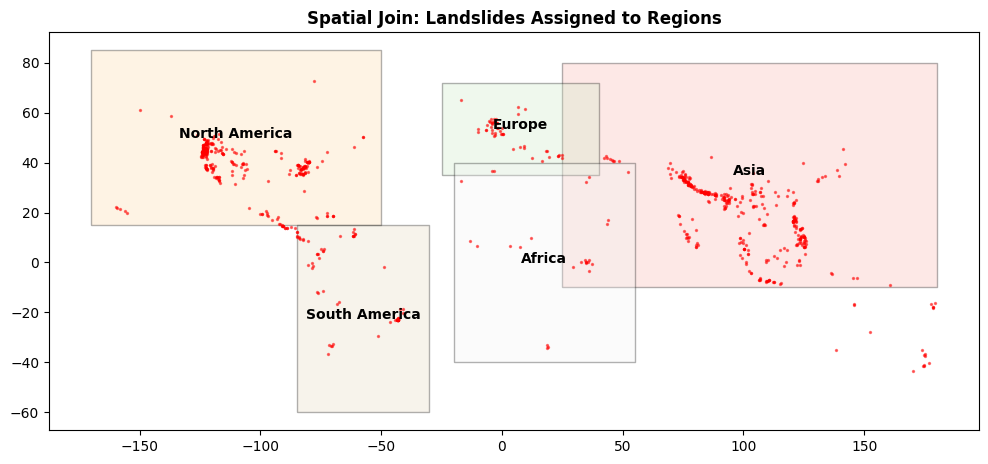

In [29]:
# Spatial Join Example: Assign each landslide to a continent

# Step 1: Create continent polygons (simplified bounding boxes)
regions = {
    'Asia': Polygon([(25, -10), (180, -10), (180, 80), (25, 80)]),
    'Europe': Polygon([(-25, 35), (40, 35), (40, 72), (-25, 72)]),
    'North America': Polygon([(-170, 15), (-50, 15), (-50, 85), (-170, 85)]),
    'South America': Polygon([(-85, -60), (-30, -60), (-30, 15), (-85, 15)]),
    'Africa': Polygon([(-20, -40), (55, -40), (55, 40), (-20, 40)])
}

regions_gdf = gpd.GeoDataFrame(
    {'region': list(regions.keys())},
    geometry=list(regions.values()),
    crs='EPSG:4326'
)

# Step 2: Perform spatial join
# This adds the 'region' column to each landslide based on which polygon it falls within
joined = gpd.sjoin(gdf, regions_gdf, how='left', predicate='within')

print("Spatial Join Results - Landslides by Region:")
print(joined['region'].value_counts())
print(f"\nUnassigned (outside defined regions): {joined['region'].isna().sum()}")

# Step 3: Visualize
fig, ax = plt.subplots(figsize=(12, 6))
regions_gdf.plot(ax=ax, alpha=0.3, edgecolor='black', cmap='Pastel1')
gdf.sample(min(800, len(gdf))).plot(ax=ax, markersize=2, color='red', alpha=0.5)
for idx, row in regions_gdf.iterrows():
    ax.annotate(row['region'], (row.geometry.centroid.x, row.geometry.centroid.y), 
                fontsize=10, ha='center', fontweight='bold')
ax.set_title('Spatial Join: Landslides Assigned to Regions', fontweight='bold')
plt.show()

Query 1: Landslides in Asia = 4497 out of 9564 total
Query 2: Landslides near Mumbai (5°) = 102
Query 3: Landslides along route = 508


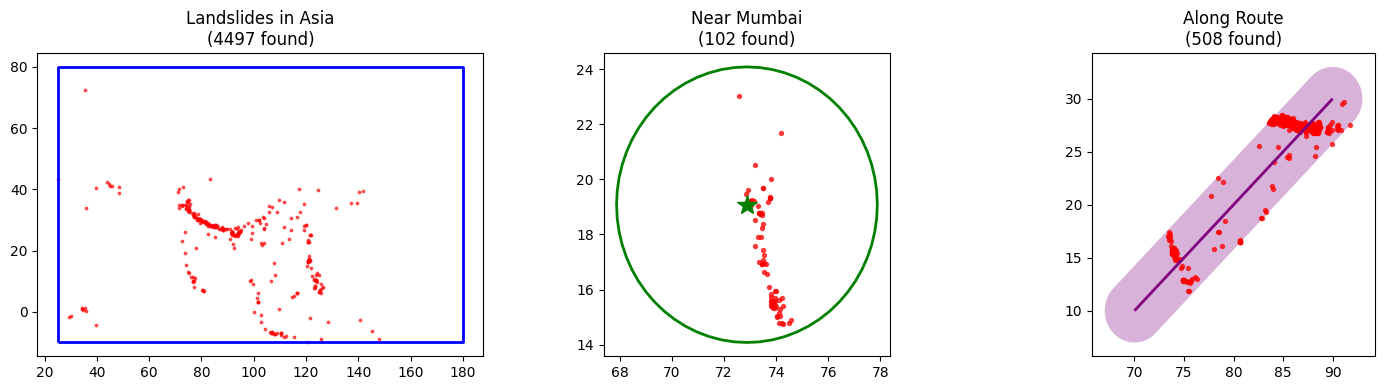

In [30]:
# Spatial Queries: Filtering data by location

# Query 1: Find all landslides in Asia
asia_polygon = regions['Asia']
asia_landslides = gdf[gdf.geometry.within(asia_polygon)]
print(f"Query 1: Landslides in Asia = {len(asia_landslides)} out of {len(gdf)} total")

# Query 2: Find landslides near Mumbai (within 5 degrees ≈ 500km)
mumbai = Point(72.88, 19.08)
mumbai_buffer = mumbai.buffer(5)  # 5 degree radius
near_mumbai = gdf[gdf.geometry.within(mumbai_buffer)]
print(f"Query 2: Landslides near Mumbai (5°) = {len(near_mumbai)}")

# Query 3: Find landslides that intersect a route/line
route = LineString([(70, 10), (90, 30)])  # Example route across South Asia
route_buffer = route.buffer(3)  # 3 degree buffer around route
along_route = gdf[gdf.geometry.within(route_buffer)]
print(f"Query 3: Landslides along route = {len(along_route)}")

# Visualize all queries
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Query 1
gpd.GeoSeries([asia_polygon]).boundary.plot(ax=axes[0], color='blue', linewidth=2)
asia_landslides.sample(min(300, len(asia_landslides))).plot(ax=axes[0], markersize=3, color='red', alpha=0.6)
axes[0].set_title(f'Landslides in Asia\n({len(asia_landslides)} found)')

# Query 2
gpd.GeoSeries([mumbai_buffer]).boundary.plot(ax=axes[1], color='green', linewidth=2)
axes[1].plot(72.88, 19.08, 'g*', markersize=15)
near_mumbai.plot(ax=axes[1], markersize=8, color='red', alpha=0.7)
axes[1].set_title(f'Near Mumbai\n({len(near_mumbai)} found)')

# Query 3
gpd.GeoSeries([route_buffer]).plot(ax=axes[2], alpha=0.3, color='purple')
gpd.GeoSeries([route]).plot(ax=axes[2], color='purple', linewidth=2)
along_route.plot(ax=axes[2], markersize=8, color='red', alpha=0.7)
axes[2].set_title(f'Along Route\n({len(along_route)} found)')

plt.tight_layout()
plt.show()

## Part 6: Distance and Buffer Calculations

### Measuring Distance on a Curved Earth
Simple Euclidean distance ($\sqrt{(x_2-x_1)^2 + (y_2-y_1)^2}$) doesn't work on Earth because Earth is curved!

### The Haversine Formula
Calculates the **great-circle distance** (shortest path on Earth's surface) between two points:

$$d = 2r \cdot \arcsin\left(\sqrt{\sin^2\left(\frac{\phi_2-\phi_1}{2}\right) + \cos(\phi_1)\cos(\phi_2)\sin^2\left(\frac{\lambda_2-\lambda_1}{2}\right)}\right)$$

Where:
- $r$ = Earth's radius (6,371 km)
- $\phi$ = latitude in radians
- $\lambda$ = longitude in radians

### What is a Buffer?
A **buffer** creates a zone of specified distance around a feature.

| Feature Type | Buffer Result |
|--------------|---------------|
| Point | Circle |
| Line | Rectangle with rounded ends |
| Polygon | Larger polygon (expanded) |

### Important: CRS Matters for Buffers!
| CRS | buffer(1) means | Use case |
|-----|-----------------|----------|
| EPSG:4326 | 1 degree (~111 km at equator, varies!) | Approximate only |
| UTM/Projected | 1 meter | Accurate measurements |

**Always convert to a projected CRS (meters) before creating buffers!**

In [31]:
# Distance Calculations using Haversine Formula

def haversine_distance(lat1, lon1, lat2, lon2):
    """Calculate great-circle distance between two points in kilometers."""
    R = 6371  # Earth's radius in km
    
    # Convert to radians
    lat1, lat2, lon1, lon2 = map(np.radians, [lat1, lat2, lon1, lon2])
    
    # Haversine formula
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    return R * 2 * np.arcsin(np.sqrt(a))

# Example: Calculate distances between major cities
cities = {
    'Mumbai': (19.08, 72.88),
    'Delhi': (28.61, 77.21),
    'Tokyo': (35.68, 139.69),
    'New York': (40.71, -74.00)
}

print("Distance between cities (km):")
print("-" * 40)
print(f"Mumbai to Delhi:    {haversine_distance(19.08, 72.88, 28.61, 77.21):,.0f} km")
print(f"Mumbai to Tokyo:    {haversine_distance(19.08, 72.88, 35.68, 139.69):,.0f} km")
print(f"Tokyo to New York:  {haversine_distance(35.68, 139.69, 40.71, -74.00):,.0f} km")

# Calculate distance from Mumbai to all landslides
gdf['dist_from_mumbai_km'] = gdf.apply(
    lambda row: haversine_distance(19.08, 72.88, row['latitude'], row['longitude']), axis=1
)

print(f"\nDistance from Mumbai to landslides:")
print(f"  Closest:  {gdf['dist_from_mumbai_km'].min():,.0f} km")
print(f"  Farthest: {gdf['dist_from_mumbai_km'].max():,.0f} km")
print(f"  Average:  {gdf['dist_from_mumbai_km'].mean():,.0f} km")

Distance between cities (km):
----------------------------------------
Mumbai to Delhi:    1,147 km
Mumbai to Tokyo:    6,723 km
Tokyo to New York:  10,850 km

Distance from Mumbai to landslides:
  Closest:  2 km
  Farthest: 16,711 km
  Average:  8,179 km


Converted to UTM Zone 43N for accurate meter-based calculations


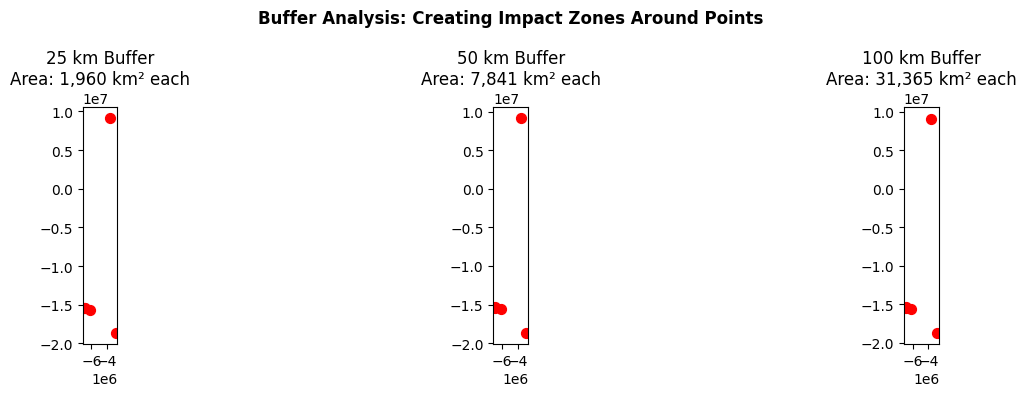


Landslides within 100km of sample point: 116


In [32]:
# Buffer Analysis

# IMPORTANT: Convert to projected CRS for accurate buffers in meters
gdf_utm = gdf.to_crs('EPSG:32643')  # UTM Zone 43N (good for India)
print("Converted to UTM Zone 43N for accurate meter-based calculations")

# Create buffers of different sizes
sample_points = gdf_utm.head(5)
buffer_sizes = [25000, 50000, 100000]  # 25km, 50km, 100km in meters

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, buffer_meters in enumerate(buffer_sizes):
    buffered = sample_points.buffer(buffer_meters)
    
    # Calculate area
    area_km2 = buffered.iloc[0].area / 1e6  # m² to km²
    
    # Plot
    gpd.GeoSeries(buffered).plot(ax=axes[i], alpha=0.3, color='blue', edgecolor='blue')
    sample_points.plot(ax=axes[i], color='red', markersize=50)
    axes[i].set_title(f'{buffer_meters/1000:.0f} km Buffer\nArea: {area_km2:,.0f} km² each')
    axes[i].set_aspect('equal')
    axes[i].ticklabel_format(style='sci', axis='both', scilimits=(0,0))

plt.suptitle('Buffer Analysis: Creating Impact Zones Around Points', fontweight='bold')
plt.tight_layout()
plt.show()

# Practical example: Count landslides within 100km of Delhi
delhi_utm = gdf_utm[gdf['countryname'] == 'India'].head(1).geometry.iloc[0].centroid
delhi_buffer = delhi_utm.buffer(100000)  # 100km
landslides_near_delhi = gdf_utm[gdf_utm.geometry.within(delhi_buffer)]
print(f"\nLandslides within 100km of sample point: {len(landslides_near_delhi)}")

## Part 7: Choropleth Mapping

### What is a Choropleth Map?
A **choropleth map** uses color shading to represent data values across geographic regions.
The name comes from Greek: *choros* (area) + *plethos* (multitude).

### Color Scheme Types
| Type | Use Case | Example |
|------|----------|---------|
| **Sequential** | Low → High values | Population density (light to dark) |
| **Diverging** | Values above/below a midpoint | Temperature anomaly (blue-white-red) |
| **Qualitative** | Categories (no order) | Land use types |

### Classification Methods
| Method | Description | Best For |
|--------|-------------|----------|
| **Equal Interval** | Same range per class | Evenly distributed data |
| **Quantiles** | Same count per class | Skewed data |
| **Natural Breaks** | Groups by clusters | Data with natural groupings |

### Best Practices
1. Use **3-7 color classes** (too many is confusing)
2. Always include a **legend**
3. Consider **colorblind-friendly** palettes (avoid red-green)
4. **Normalize data** when comparing different-sized regions (use rates, not totals)

Top 10 countries by landslide count:
       country  landslide_count
 United States             3021
         India             1273
   Philippines              676
         Nepal              483
         China              426
     Indonesia              356
United Kingdom              231
        Brazil              214
        Canada              174
      Malaysia              172


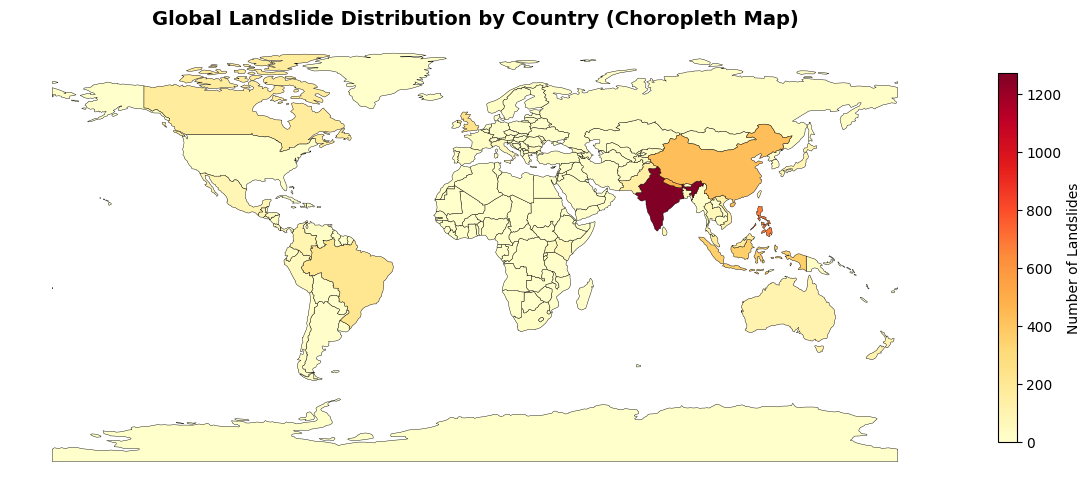

In [33]:
# Creating a Choropleth Map

# Step 1: Aggregate data by country
country_stats = gdf.groupby('countryname').agg({
    'id': 'count',
    'fatalities': 'sum'
}).reset_index()
country_stats.columns = ['country', 'landslide_count', 'total_fatalities']

print("Top 10 countries by landslide count:")
print(country_stats.nlargest(10, 'landslide_count')[['country', 'landslide_count']].to_string(index=False))

# Step 2: Load world map
world = gpd.read_file('https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip')

# Step 3: Merge landslide data with world polygons
world_data = world.merge(country_stats, left_on='NAME', right_on='country', how='left')
world_data['landslide_count'] = world_data['landslide_count'].fillna(0)

# Step 4: Create choropleth map
fig, ax = plt.subplots(figsize=(15, 8))

world_data.plot(
    column='landslide_count',
    ax=ax,
    legend=True,
    cmap='YlOrRd',  # Yellow-Orange-Red sequential colormap
    edgecolor='black',
    linewidth=0.3,
    missing_kwds={'color': 'lightgray'},
    legend_kwds={'label': 'Number of Landslides', 'shrink': 0.6}
)

ax.set_title('Global Landslide Distribution by Country (Choropleth Map)', fontsize=14, fontweight='bold')
ax.axis('off')
plt.show()

## Part 8: Point and Polygon Data Visualization

### Point Visualization Techniques
| Technique | When to Use | GeoPandas Parameter |
|-----------|-------------|---------------------|
| **Simple markers** | All points are equal | `color='red'` |
| **Categorical colors** | Points belong to categories | `column='category', categorical=True` |
| **Graduated colors** | Color varies by value | `column='value', cmap='viridis'` |
| **Graduated size** | Size varies by value | Set `markersize` based on column |
| **Density/Heatmap** | Show concentration | Use hexbin or kernel density |

### Polygon Visualization Techniques
| Technique | When to Use |
|-----------|-------------|
| **Simple fill** | Show boundaries only |
| **Choropleth** | Color by numeric value |
| **Categorical** | Color by category |
| **Boundary only** | Overlay with point data |

### Key Parameters in GeoPandas `.plot()`
| Parameter | Purpose | Example |
|-----------|---------|---------|
| `column` | Column to visualize | `column='population'` |
| `cmap` | Color palette | `cmap='viridis'` |
| `alpha` | Transparency (0-1) | `alpha=0.5` |
| `markersize` | Point size | `markersize=10` |
| `edgecolor` | Border color | `edgecolor='black'` |
| `legend` | Show legend | `legend=True` |

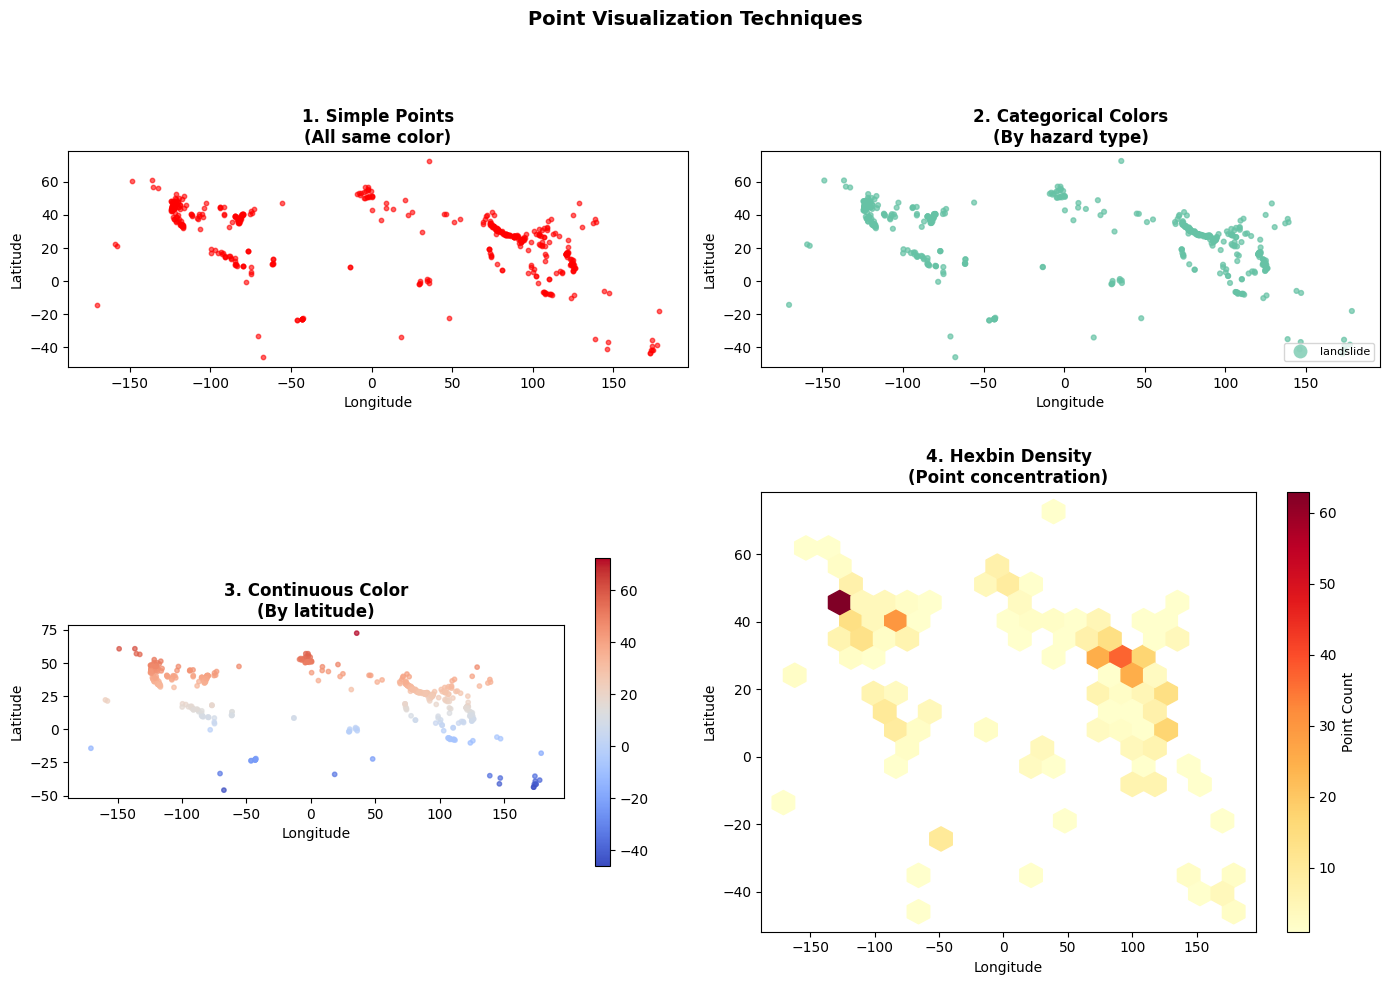

In [34]:
# Point Visualization Techniques

sample = gdf.sample(min(500, len(gdf)), random_state=42)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Simple Points (all same color)
sample.plot(ax=axes[0,0], markersize=10, color='red', alpha=0.6)
axes[0,0].set_title('1. Simple Points\n(All same color)', fontweight='bold')

# 2. Categorical Colors (by hazard type)
sample.plot(ax=axes[0,1], column='hazard_type', markersize=12, legend=True, 
            cmap='Set2', alpha=0.7, categorical=True,
            legend_kwds={'fontsize': 8, 'loc': 'lower right'})
axes[0,1].set_title('2. Categorical Colors\n(By hazard type)', fontweight='bold')

# 3. Continuous Color (by latitude)
sample.plot(ax=axes[1,0], column='latitude', markersize=10, cmap='coolwarm', 
            alpha=0.7, legend=True, legend_kwds={'shrink': 0.7})
axes[1,0].set_title('3. Continuous Color\n(By latitude)', fontweight='bold')

# 4. Density (Hexbin)
hb = axes[1,1].hexbin(sample.geometry.x, sample.geometry.y, gridsize=20, cmap='YlOrRd', mincnt=1)
plt.colorbar(hb, ax=axes[1,1], label='Point Count')
axes[1,1].set_title('4. Hexbin Density\n(Point concentration)', fontweight='bold')

for ax in axes.flat:
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')

plt.suptitle('Point Visualization Techniques', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

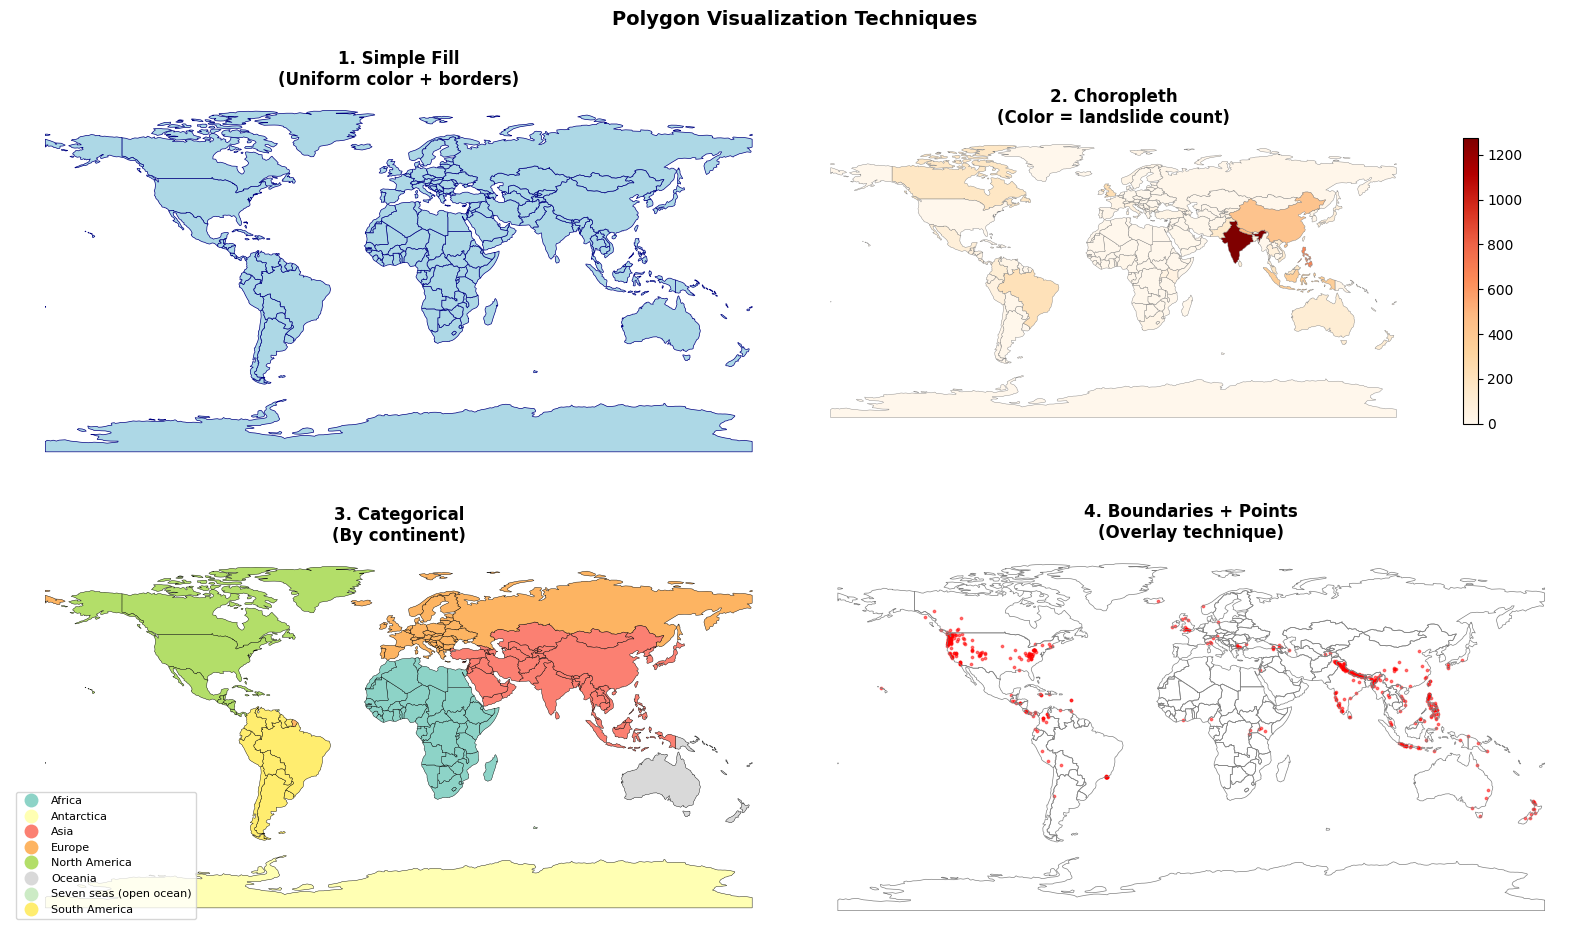

In [35]:
# Polygon Visualization Techniques

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Simple Fill
world.plot(ax=axes[0,0], color='lightblue', edgecolor='navy', linewidth=0.5)
axes[0,0].set_title('1. Simple Fill\n(Uniform color + borders)', fontweight='bold')
axes[0,0].axis('off')

# 2. Choropleth (color by value)
world_data.plot(ax=axes[0,1], column='landslide_count', cmap='OrRd', 
                edgecolor='gray', linewidth=0.3, legend=True, legend_kwds={'shrink': 0.6})
axes[0,1].set_title('2. Choropleth\n(Color = landslide count)', fontweight='bold')
axes[0,1].axis('off')

# 3. Categorical (by continent)
world.plot(ax=axes[1,0], column='CONTINENT', categorical=True, cmap='Set3',
           edgecolor='black', linewidth=0.3, legend=True,
           legend_kwds={'fontsize': 8, 'loc': 'lower left'})
axes[1,0].set_title('3. Categorical\n(By continent)', fontweight='bold')
axes[1,0].axis('off')

# 4. Boundaries + Point Overlay
world.boundary.plot(ax=axes[1,1], color='gray', linewidth=0.5)
gdf.sample(min(500, len(gdf))).plot(ax=axes[1,1], markersize=3, color='red', alpha=0.5)
axes[1,1].set_title('4. Boundaries + Points\n(Overlay technique)', fontweight='bold')
axes[1,1].axis('off')

plt.suptitle('Polygon Visualization Techniques', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Part 9: Geocoding and Reverse Geocoding

### What is Geocoding?
**Geocoding** = Converting addresses/place names → Geographic coordinates

```
Input:  "Taj Mahal, Agra, India"
Output: (27.1751, 78.0421)
```

### What is Reverse Geocoding?
**Reverse Geocoding** = Converting coordinates → Address/place name

```
Input:  (27.1751, 78.0421)
Output: "Taj Mahal, Agra, Uttar Pradesh, India"
```

### Geocoding Services
| Service | Free Tier | Notes |
|---------|-----------|-------|
| **Nominatim (OSM)** | Unlimited (rate limited) | Open source, use responsibly |
| **Google Maps** | $200/month credit | High accuracy |
| **Mapbox** | 100k/month | Good for web apps |

### Python Library: geopy
```python
from geopy.geocoders import Nominatim

# Setup
geolocator = Nominatim(user_agent="my_app")

# Geocoding
location = geolocator.geocode("Mumbai, India")
print(location.latitude, location.longitude)

# Reverse Geocoding  
location = geolocator.reverse("19.076, 72.877")
print(location.address)
```

### Important Considerations
- **Rate limiting**: Most services limit requests per second
- **Caching**: Store results to avoid repeated API calls
- **Accuracy**: Varies by region and service

In [36]:
# Geocoding Demonstration (Conceptual - showing the approach)

print("=" * 60)
print("GEOCODING: Address → Coordinates")
print("=" * 60)
from geopy.geocoders import Nominatim
geolocator = Nominatim(user_agent="my_app")

# Geocode an address
location = geolocator.geocode("India Gate, New Delhi")
print(location.latitude, location.longitude)  # Output: 28.6129, 77.2295

print("=" * 60)
print("REVERSE GEOCODING: Coordinates → Address")
print("=" * 60)
location = geolocator.reverse("28.6129, 77.2295")
print(location.address)  # Output: "India Gate, Rajpath, New Delhi, Delhi, India"

GEOCODING: Address → Coordinates
28.6129332 77.2294928
REVERSE GEOCODING: Coordinates → Address
India Gate, Shahjahan Road, Chanakya Puri Tehsil, New Delhi, Delhi, 020626, India


## Part 10: Raster and Vector Data Handling

### Detailed Comparison

| Aspect | Vector | Raster |
|--------|--------|--------|
| **Data Model** | Discrete objects (points, lines, polygons) | Continuous grid of cells |
| **Representation** | Coordinates define shapes | Pixel values in matrix |
| **Resolution** | Infinite (mathematically precise) | Fixed (cell size determines detail) |
| **File Size** | Generally smaller | Can be very large |
| **Best for** | Boundaries, networks, discrete features | Imagery, elevation, continuous surfaces |

### Vector Data with GeoPandas/Shapely
```python
# Read vector data
gdf = gpd.read_file('countries.shp')

# Create geometries with Shapely
from shapely.geometry import Point, Polygon, LineString

point = Point(77.21, 28.61)           # Delhi
line = LineString([(72.88, 19.08), (77.21, 28.61)])  # Mumbai to Delhi route
polygon = Polygon([(0, 0), (1, 0), (1, 1), (0, 1)])  # Square region
```

### Raster Data with Rasterio
```python
import rasterio

# Read raster file (satellite image, elevation, etc.)
with rasterio.open('elevation.tif') as src:
    data = src.read(1)        # Read first band as numpy array
    transform = src.transform # Geographic reference
    crs = src.crs             # Coordinate system
```

Creating Geometries with Shapely:
--------------------------------------------------
Point (Delhi): POINT (77.21 28.61)
  Coordinates: X=77.21, Y=28.61

LineString (Route): LINESTRING (72.88 19.08, 74.5 22, 77.21 28.61)
  Length (degrees): 10.48

Polygon (Region): POLYGON ((74 18, 80 18, 80 30, 74 30, 74 18))
  Area (sq degrees): 72.00
  Centroid: POINT (77 24)

Geometric Operations:
--------------------------------------------------
Is Delhi within the region? True
Does route intersect region? True
Distance from Mumbai to Delhi (degrees): 10.47


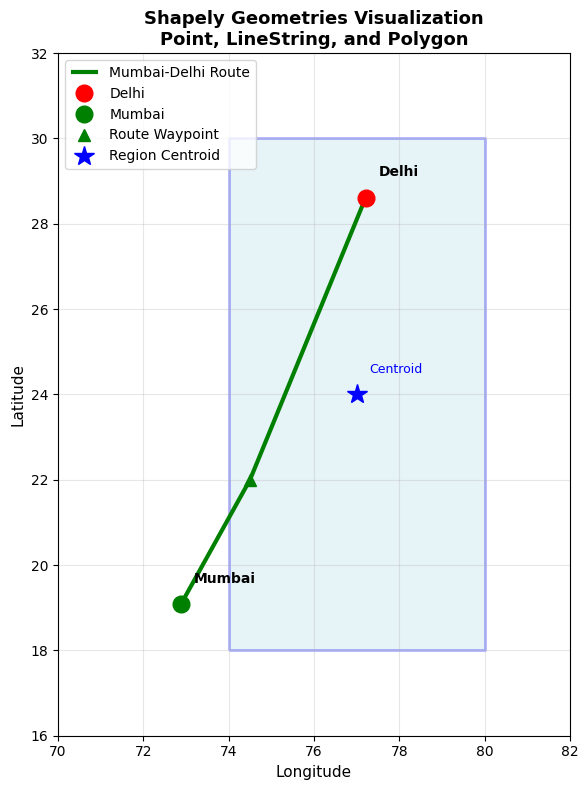

In [41]:
# Vector Data Operations with Shapely

from shapely.geometry import Point, LineString, Polygon
from shapely.ops import unary_union

# Creating different geometry types
print("Creating Geometries with Shapely:")
print("-" * 50)

# Point
delhi = Point(77.21, 28.61)
print(f"Point (Delhi): {delhi}")
print(f"  Coordinates: X={delhi.x}, Y={delhi.y}")

# LineString (a path/route)
mumbai_delhi_route = LineString([(72.88, 19.08), (74.5, 22.0), (77.21, 28.61)])
print(f"\nLineString (Route): {mumbai_delhi_route}")
print(f"  Length (degrees): {mumbai_delhi_route.length:.2f}")

# Polygon (an area)
region = Polygon([(74, 18), (80, 18), (80, 30), (74, 30)])
print(f"\nPolygon (Region): {region}")
print(f"  Area (sq degrees): {region.area:.2f}")
print(f"  Centroid: {region.centroid}")

# Geometric operations
print("\nGeometric Operations:")
print("-" * 50)
print(f"Is Delhi within the region? {delhi.within(region)}")
print(f"Does route intersect region? {mumbai_delhi_route.intersects(region)}")
print(f"Distance from Mumbai to Delhi (degrees): {Point(72.88, 19.08).distance(delhi):.2f}")

# Visualize the shapes
fig, ax = plt.subplots(figsize=(10, 8))

# Plot the polygon (region)
gpd.GeoSeries([region]).plot(ax=ax, alpha=0.3, color='lightblue', edgecolor='blue', linewidth=2, label='Region')

# Plot the line (route)
gpd.GeoSeries([mumbai_delhi_route]).plot(ax=ax, color='green', linewidth=3, label='Mumbai-Delhi Route')

# Plot the points
mumbai = Point(72.88, 19.08)
ax.plot(delhi.x, delhi.y, 'ro', markersize=12, label='Delhi', zorder=5)
ax.plot(mumbai.x, mumbai.y, 'go', markersize=12, label='Mumbai', zorder=5)
ax.plot(74.5, 22.0, 'g^', markersize=8, label='Route Waypoint', zorder=5)

# Plot centroid
centroid = region.centroid
ax.plot(centroid.x, centroid.y, 'b*', markersize=15, label='Region Centroid', zorder=5)

# Add annotations
ax.annotate('Delhi', (delhi.x + 0.3, delhi.y + 0.5), fontsize=10, fontweight='bold')
ax.annotate('Mumbai', (mumbai.x + 0.3, mumbai.y + 0.5), fontsize=10, fontweight='bold')
ax.annotate('Centroid', (centroid.x + 0.3, centroid.y + 0.5), fontsize=9, color='blue')

# Styling
ax.set_xlabel('Longitude', fontsize=11)
ax.set_ylabel('Latitude', fontsize=11)
ax.set_title('Shapely Geometries Visualization\nPoint, LineString, and Polygon', fontsize=13, fontweight='bold')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)
ax.set_xlim(70, 82)
ax.set_ylim(16, 32)

plt.tight_layout()
plt.show()

## Part 11: Interactive Maps with Folium

### What is Folium?
**Folium** is a Python library that creates **interactive web maps** using Leaflet.js.
Unlike matplotlib (static images), Folium maps can be zoomed, panned, and clicked.

### Key Features
| Feature | Description |
|---------|-------------|
| **Base maps** | OpenStreetMap, Satellite, Terrain, etc. |
| **Markers** | Points with popups and custom icons |
| **Choropleth** | Interactive colored regions |
| **GeoJSON** | Overlay any vector data |
| **Plugins** | Heatmaps, marker clusters, draw tools |

### Basic Syntax
```python
import folium

# Create map centered on India
m = folium.Map(location=[20.5937, 78.9629], zoom_start=5)

# Add marker
folium.Marker([28.61, 77.21], popup='Delhi').add_to(m)

# Add circle
folium.Circle([19.08, 72.88], radius=50000, popup='Mumbai').add_to(m)

# Display in notebook
m
```

In [38]:
# Interactive Map with Folium

# Create base map centered on Asia
m = folium.Map(
    location=[25, 80],  # Center of India roughly
    zoom_start=4,
    tiles='OpenStreetMap'
)

# Add sample landslide points as markers
sample_folium = gdf.sample(min(100, len(gdf)), random_state=42)

for idx, row in sample_folium.iterrows():
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=5,
        color='red',
        fill=True,
        fillOpacity=0.7,
        popup=f"Country: {row['countryname']}<br>Type: {row['hazard_type']}"
    ).add_to(m)

# Add a few city markers for reference
cities = {
    'Mumbai': [19.08, 72.88],
    'Delhi': [28.61, 77.21],
    'Tokyo': [35.68, 139.69],
    'Jakarta': [-6.20, 106.85]
}

for city, coords in cities.items():
    folium.Marker(
        location=coords,
        popup=city,
        icon=folium.Icon(color='blue', icon='info-sign')
    ).add_to(m)

print("Interactive Folium Map (zoom and click on markers!):")
m

Interactive Folium Map (zoom and click on markers!):


## Part 12: Integration of Geospatial Data with Other Data Sources

### Why Integrate Data?
Geospatial analysis becomes powerful when you combine location data with other datasets:
- **Census data** + Location → Population density maps
- **Weather data** + Location → Climate analysis
- **Business data** + Location → Market analysis

### Common Integration Patterns

| Pattern | Description | Example |
|---------|-------------|---------|
| **Attribute Join** | Join by common column | Add population to country polygons |
| **Spatial Join** | Join by location | Find which district each point belongs to |
| **API Integration** | Fetch external data | Get weather for each location |
| **Aggregation** | Summarize by region | Count events per country |

### Example Workflow
```python
# 1. Load spatial data (boundaries)
districts = gpd.read_file('districts.shp')

# 2. Load tabular data
population = pd.read_csv('population.csv')

# 3. Merge on common column
districts = districts.merge(population, on='district_id')

# 4. Calculate derived metrics
districts['density'] = districts['population'] / districts['area_km2']

# 5. Visualize
districts.plot(column='density', cmap='YlOrRd', legend=True)
```

Integrated Data: Landslides + Economic Indicators
----------------------------------------------------------------------
      country  total_landslides  total_fatalities  total_injuries  gdp_billion_usd  population_million  landslides_per_million
        China               426            4944.0           318.0            17960                1412                    0.30
        India              1273            7090.0           218.0             3385                1408                    0.90
    Indonesia               356            1697.0           147.0             1319                 273                    1.30
        Japan                82             223.0            10.0             4230                 125                    0.66
        Nepal               483            1533.0           283.0               36                  30                   16.10
  Philippines               676            1847.0           137.0              404                 115               

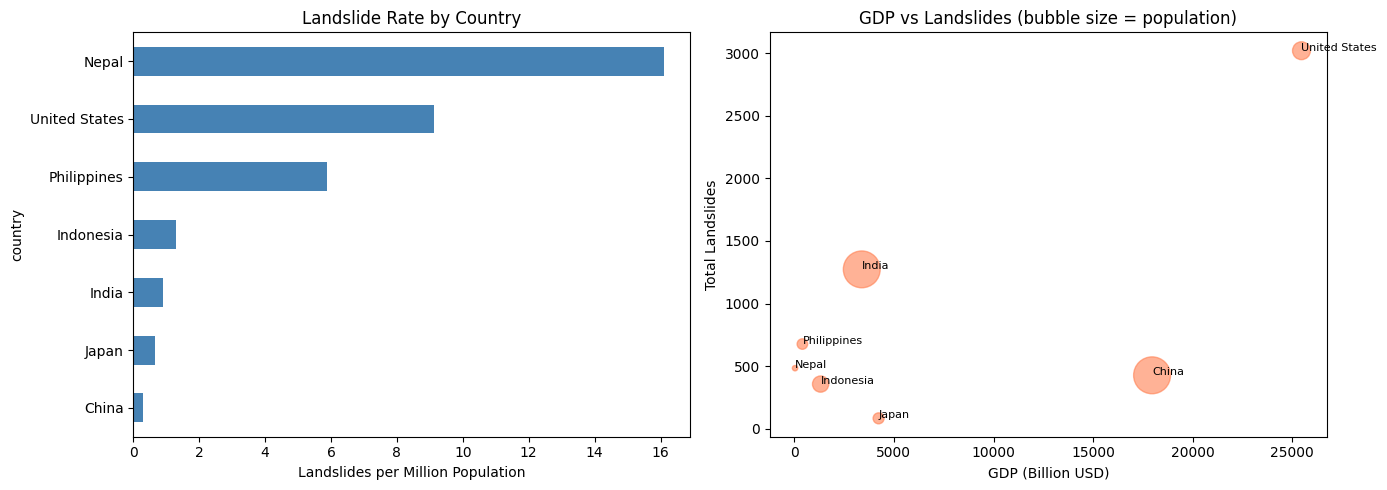

In [40]:
# Data Integration Example: Combining Landslide Data with Country Statistics

# Step 1: Create aggregated statistics from our landslide data
landslide_stats = gdf.groupby('countryname').agg({
    'id': 'count',
    'fatalities': 'sum',
    'injuries': 'sum'
}).reset_index()
landslide_stats.columns = ['country', 'total_landslides', 'total_fatalities', 'total_injuries']

# Step 2: Create simulated external data (in real scenario, this would come from an API or file)
# GDP data (simplified, for demonstration)
gdp_data = pd.DataFrame({
    'country': ['India', 'United States', 'China', 'Japan', 'Philippines', 'Nepal', 'Indonesia'],
    'gdp_billion_usd': [3385, 25460, 17960, 4230, 404, 36, 1319],
    'population_million': [1408, 331, 1412, 125, 115, 30, 273]
})

# Step 3: Merge datasets
integrated_data = landslide_stats.merge(gdp_data, on='country', how='inner')

# Step 4: Calculate derived metrics
integrated_data['landslides_per_million'] = (
    integrated_data['total_landslides'] / integrated_data['population_million']
).round(2)

print("Integrated Data: Landslides + Economic Indicators")
print("-" * 70)
print(integrated_data.to_string(index=False))

# Step 5: Visualize relationship
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1: Landslides per million population
integrated_data.sort_values('landslides_per_million', ascending=True).plot(
    kind='barh', x='country', y='landslides_per_million', ax=axes[0], color='steelblue', legend=False
)
axes[0].set_xlabel('Landslides per Million Population')
axes[0].set_title('Landslide Rate by Country')

# Chart 2: Scatter of GDP vs Landslides
axes[1].scatter(integrated_data['gdp_billion_usd'], integrated_data['total_landslides'], 
                s=integrated_data['population_million']*0.5, alpha=0.6, c='coral')
for i, row in integrated_data.iterrows():
    axes[1].annotate(row['country'], (row['gdp_billion_usd'], row['total_landslides']), fontsize=8)
axes[1].set_xlabel('GDP (Billion USD)')
axes[1].set_ylabel('Total Landslides')
axes[1].set_title('GDP vs Landslides (bubble size = population)')

plt.tight_layout()
plt.show()